# 🏠 House Price Prediction using Multiple Regression Models

## AI & Machine Learning Internship – Task 2

### Objective
The objective of this project is to compare multiple machine learning regression models for predicting California housing prices. The models are evaluated using RMSE and R² Score to determine the best-performing model.

## Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [4]:
print(fetch_california_housing)

<function fetch_california_housing at 0x0000021C34F99BC0>


## Step 2: Load the California Housing Dataset

The California Housing Dataset is a popular regression dataset provided by Scikit-learn. It contains housing-related information such as median income, house age, average rooms, and population. The goal is to predict the median house value.

In [5]:
# Load the California Housing Dataset
housing = fetch_california_housing(as_frame=True)

# Store the dataset as a pandas DataFrame
df = housing.frame

# Display the first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Exploratory Data Analysis (EDA)

Before building machine learning models, it is important to understand the dataset. In this step, we will examine the dataset's dimensions, data types, missing values, and summary statistics.

In [7]:
# Display the shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (20640, 9)


In [8]:
# Display information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [9]:
# Check for missing values
df.isnull().sum()


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [10]:
# Display summary statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [11]:
# Display the first 10 rows
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


## Step 4: Data Preprocessing

Machine learning models require input features (X) and a target variable (y). In this project, the housing attributes are used as input features, while the median house value is the target variable to be predicted.

In [12]:
# Separate features (X) and target variable (y)

X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

In [13]:
# Display feature names

print("Features:")
print(X.columns)

Features:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')


In [14]:
# Display target variable

print("Target Variable:")
print(y.head())

Target Variable:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


## Step 5: Feature Scaling

Feature scaling standardizes the numerical features so that they have a mean of 0 and a standard deviation of 1. This helps machine learning algorithms treat all features equally and often improves model performance.

In [15]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create the scaler object
scaler = StandardScaler()

# Scale the feature variables
X_scaled = scaler.fit_transform(X)

# Display the first five scaled rows
print(X_scaled[:5])

[[ 2.34476576  0.98214266  0.62855945 -0.15375759 -0.9744286  -0.04959654
   1.05254828 -1.32783522]
 [ 2.33223796 -0.60701891  0.32704136 -0.26333577  0.86143887 -0.09251223
   1.04318455 -1.32284391]
 [ 1.7826994   1.85618152  1.15562047 -0.04901636 -0.82077735 -0.02584253
   1.03850269 -1.33282653]
 [ 0.93296751  1.85618152  0.15696608 -0.04983292 -0.76602806 -0.0503293
   1.03850269 -1.33781784]
 [-0.012881    1.85618152  0.3447108  -0.03290586 -0.75984669 -0.08561576
   1.03850269 -1.33781784]]


## Step 6: Split the Dataset

The dataset is divided into training and testing sets. The training set is used to train the machine learning models, while the testing set is used to evaluate how well the models perform on unseen data.

In [16]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes of the datasets

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (16512, 8)
Testing Features: (4128, 8)
Training Target: (16512,)
Testing Target: (4128,)


## Step 7: Train Machine Learning Models

In this step, we train three different regression models on the training dataset:

- Linear Regression
- Ridge Regression
- Decision Tree Regression

These models will later be evaluated and compared to determine which one performs best.

In [17]:
# Create the regression models

linear_model = LinearRegression()

ridge_model = Ridge(alpha=1.0)

decision_tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

In [23]:

# Train the models
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)

print(" All models trained successfully!")

 All models trained successfully!


## Step 8: Model Evaluation and Comparison

After training the models, predictions are made on the testing dataset. Each model is evaluated using Root Mean Squared Error (RMSE) and R² Score. These metrics help determine which model performs best.

In [25]:
# Make predictions using all three models

linear_predictions = linear_model.predict(X_test)

ridge_predictions = ridge_model.predict(X_test)

decision_tree_predictions = decision_tree_model.predict(X_test)

In [26]:
# Evaluate Linear Regression

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

# Evaluate Ridge Regression

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
ridge_r2 = r2_score(y_test, ridge_predictions)

# Evaluate Decision Tree Regression

tree_rmse = np.sqrt(mean_squared_error(y_test, decision_tree_predictions))
tree_r2 = r2_score(y_test, decision_tree_predictions)

In [28]:
# Create a comparison table

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree"
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        tree_rmse
    ],
    "R² Score": [
        linear_r2,
        ridge_r2,
        tree_r2
    ]
})

results.sort_values(by="R² Score", ascending=False)

,Model,RMSE,R² Score
2,Decision Tree,0.724234,0.599732
1,Ridge Regression,0.745554,0.575819
0,Linear Regression,0.745581,0.575788


## Step 9: Model Performance Visualization

Visualizations make it easier to compare the performance of different machine learning models and understand how well the best model predicts house prices.

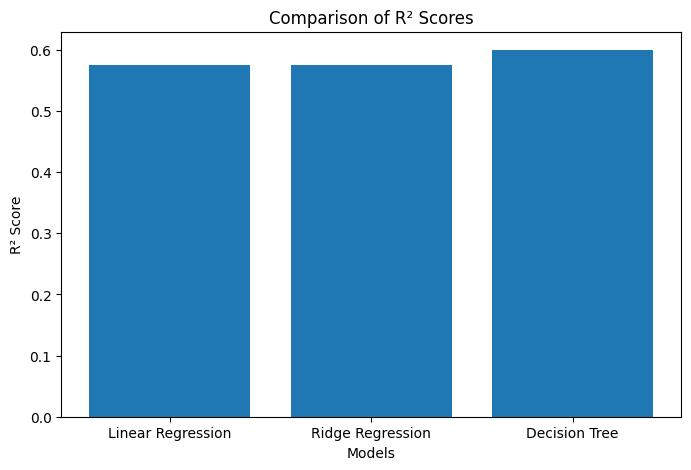

In [29]:
# Plot R² Scores of all models

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R² Score"])

plt.title("Comparison of R² Scores")

plt.xlabel("Models")

plt.ylabel("R² Score")

plt.show()

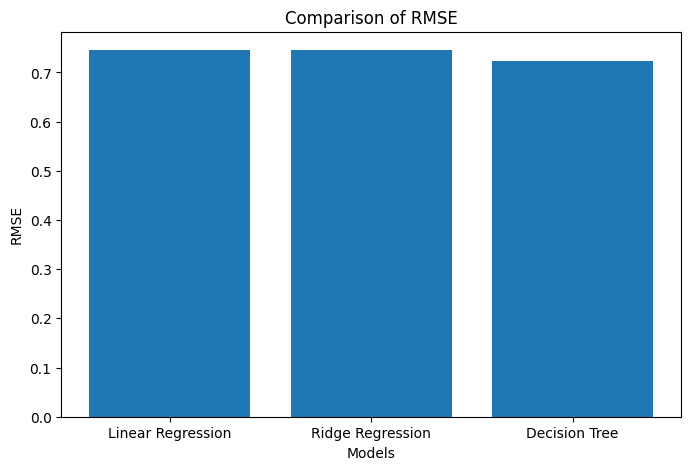

In [30]:
# Plot RMSE of all models

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.title("Comparison of RMSE")

plt.xlabel("Models")

plt.ylabel("RMSE")

plt.show()

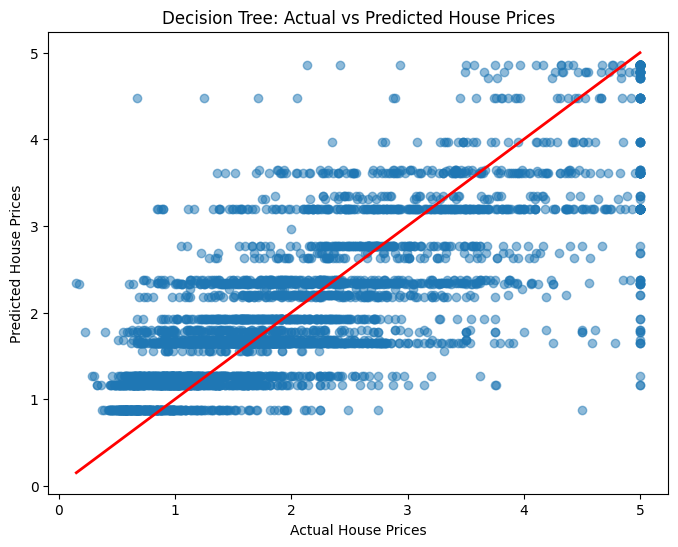

In [31]:
# Plot Actual vs Predicted values for the best model

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    decision_tree_predictions,
    alpha=0.5
)

plt.xlabel("Actual House Prices")

plt.ylabel("Predicted House Prices")

plt.title("Decision Tree: Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.show()

## Step 10: Conclusion

In this project, three regression models were trained and evaluated using the California Housing Dataset.

The models were compared using RMSE and R² Score.

Among the three models, the **Decision Tree Regressor** achieved the highest R² Score, making it the best-performing model for this dataset.

This project demonstrates the importance of preprocessing data, applying feature scaling, training multiple machine learning models, and comparing their performance before selecting the most suitable model.

## Future Improvements

- Perform hyperparameter tuning to improve model performance.
- Experiment with additional regression algorithms such as Random Forest and XGBoost.
- Use cross-validation for more reliable model evaluation.
- Deploy the trained model as a web application using Flask or Streamlit.
- Train the model on larger and more diverse housing datasets.

## References

- Scikit-learn Documentation
- California Housing Dataset
- NumPy Documentation
- Pandas Documentation
- Matplotlib Documentation